Département de génie électrique - Polytechnique Montréal

Analyse des signaux - ELE2700

TP6 version 5: A2025

#$\color{#18a2f2}{\textbf{TP6 - Filtres numériques}}$

C'est presque la fin de la session ! On ne lâche pas.

Pour vous laisser souffler, il n'y aura pas de devoir pour cette remise, toute l'évaluation se fera en classe.

##$\color{#a618f2}{\textbf{Objectifs:}}$

Les objectifs du TP sont :


1. Offrir une expérience pratique de traitement numérique de signaux;
2. Présenter des filtres d'intérêts pour des applications plus complexes.



Nous utiliserons `librosa` et `scipy.signal` pour le traitement de signaux audio et le filtrage.

Documentation à utiliser :
- https://librosa.org/doc/latest/index.html
- https://docs.scipy.org/doc/scipy/reference/signal.html#



In [ ]:
# Décommenter au besoin

#!pip install librosa
#!pip install numpy
#!pip install matplotlib
#!pip install IPython
#!pip install scipy

Les filtres numériques sont présents dans beaucoup de produits de la vie de tous les jours.

>Avant de commencer, insérer les trois fichiers audio dans le dossier *content* de Google Colab.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import librosa
import scipy.signal as ss
local = False

##$\color{#a618f2}{\textbf{Exemple pratique:}}$

Dans cet exemple, nous étudions le filtrage d'un signal parasite avec `Python`.

Imaginez que vous êtes sur la plage et que vous essayez de faire une sieste en étant bercé par le bruit des vagues.

Misère ! Il y a beaucoup de brume et des paquebots passent fréquemment à quelques kilomètres de la côte; impossible de dormir avec le vacarme des cornes de brume.

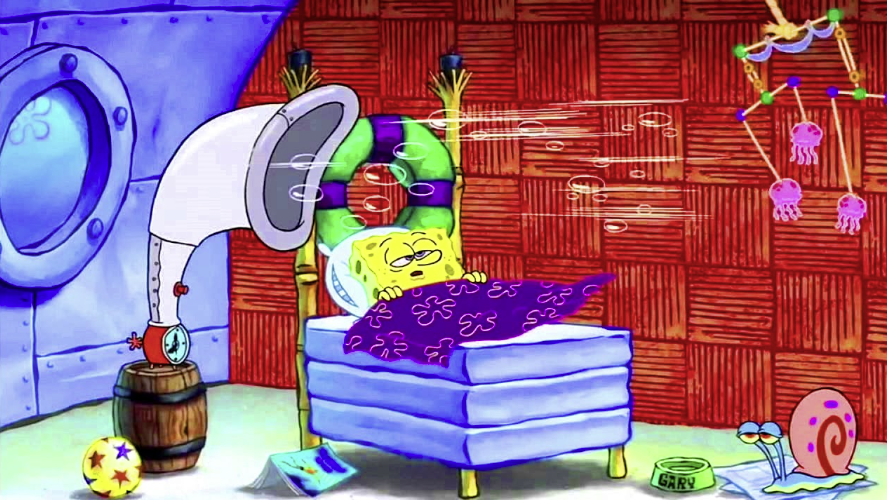

Heureusement, vous êtes de futurs ingénieur.e.s électriques et avez de bonnes compétences en analyse des signaux. Aussi, les paquebots naviguent sur une voie maritime assez restreinte et ont à peu près le même modèle de corne de brume.

Vous enregistrez un clip audio du bruit parasite pour pouvoir l'analyser avec `Python` et développer un filtre numérique pour cette tâche unique. Vous pourrez ensuite l'importer dans des écouteurs qui vous permettront de vivre en paix.

In [ ]:
from google.colab import files
uploaded = files.upload() # select downloaded files from your local environment

In [4]:
# Votre clip audio
if local:
    y, sr = librosa.load("ocean_horn.mp3", duration=30) #y = signal, sr = fréquence d'échantillonnage
else:
    y, sr = librosa.load("/content/ocean_horn.mp3", duration=30) #y = signal, sr = fréquence d'échantillonnage
print(f"Sampling rate: {sr}")

# Jouer l'extrait audio en entier
Audio(data=y[0*sr:30*sr], rate=sr)

Sampling rate: 22050


Dans ce TP, nous devrons utiliser la Short-Time Fourier Transform (STFT). Cet outil permet d'obtenir la composante fréquentielle d'un signal dans le temps et est donc très utile pour notre application: on veut pouvoir analyser comment le spectre change lorsqu'on entend la corne de brume.

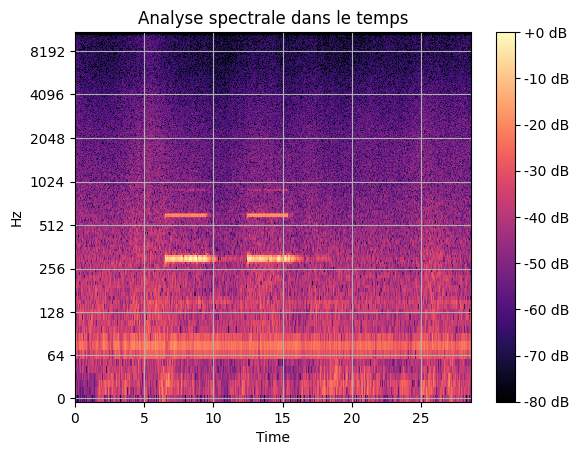

In [5]:
# Analyse du spectre dans le temps
D = librosa.stft(y)  # short-time Fourier Transform (STFT) de y
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max) #Spectre en dB

# Visualisation du spectre
fig, ax = plt.subplots()
plt.grid()
img = librosa.display.specshow(S_db, x_axis='time', y_axis='log', ax=ax) #Axe log
ax.set(title='Analyse spectrale dans le temps')
fig.colorbar(img, ax=ax, format="%+2.f dB")

Nous pouvons voir les 3 harmoniques de la corne de brume sur le graphique à partir de la 6ème seconde.

Essayons de trouver ces harmoniques afin de les filtrer par après.

Réanalysons en zoomant sur les fréquences d'intérêt.

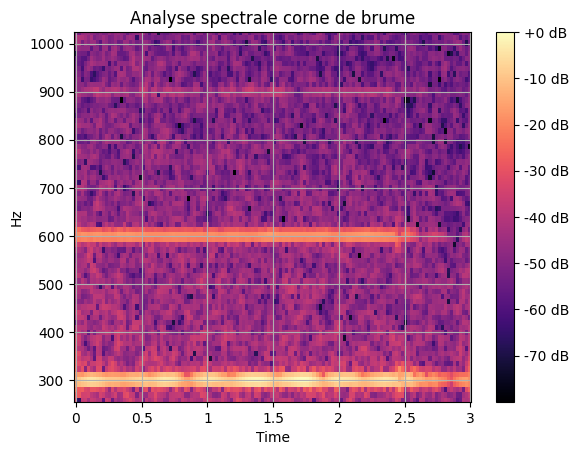

In [6]:
# Analyse du spectre entre 7 et 10 secondes (première corne de brume)
D = librosa.stft(y[7*sr:10*sr])
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

fig, ax = plt.subplots()
plt.grid()
img = librosa.display.specshow(S_db, x_axis='time', y_axis='fft', ax=ax) #axe linéaire (fft)
ax.set_ylim(bottom=255, top=1024) #zoom sur les fréquences d'intérêt

ax.set(title='Analyse spectrale corne de brume')
fig.colorbar(img, ax=ax, format="%+2.f dB")

Très clairement, nous voyons que les 3 premières harmoniques sont à environ 300, 600 et 900 Hz.

Implémentons un filtre pour les retirer.

Nous concevons un filtre réponse à l'impulsion infini (RII) (Chapitre 7) coupe-bande grâce à la librairie `scipy.signal`:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html#scipy.signal.iirdesign

Et ensuite filtrons:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.sosfilt.html#scipy.signal.sosfilt

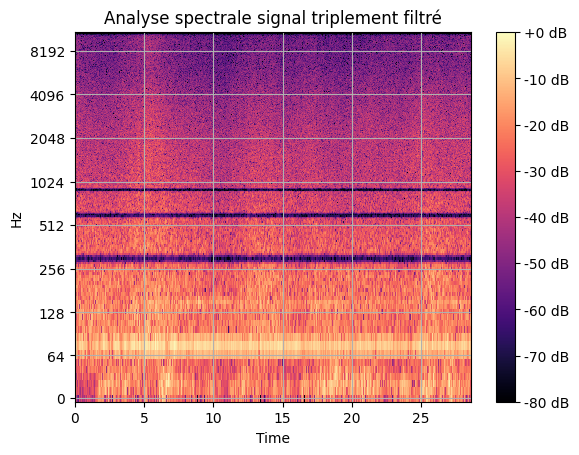

In [7]:
y_filt = y
fc = [300,600,900]
for freq in fc:
  sos_filter = ss.iirdesign(wp = [freq-30, freq+30], ws = [freq-20, freq+20] , gpass = 3, gstop = 50, analog=False, ftype='butter', output='sos', fs=sr)
  y_filt = ss.sosfilt(sos_filter, y_filt)

# Analyse du spectre filtré dans le temps
D = librosa.stft(y_filt)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
fig, ax = plt.subplots()
plt.grid()
img = librosa.display.specshow(S_db, x_axis='time', y_axis='log', ax=ax)
ax.set(title='Analyse spectrale signal triplement filtré')
fig.colorbar(img, ax=ax, format="%+2.f dB")

On remarque visuellement que les fréquences ont bien été filtrées. Il reste maintenant qu'à vérifier avec nos oreilles.

In [8]:
# Jouer l'extrait audio filtré
Audio(data=y_filt[0*sr:30*sr], rate=sr)

Nous avons réussi !

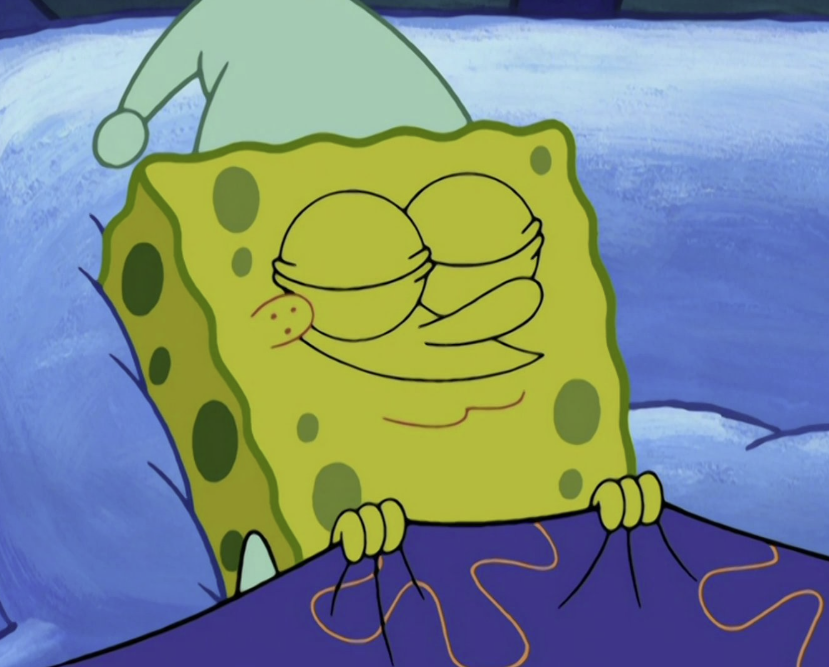

#$\color{#18a2f2}{\textbf{TP6 - Exercice}}$

## $\color{#03fc9d}{\textbf{Exercice pratique, évalué en classe (8pt/20):}}$

**Mise en contexte :**

En faisant le ménage vous trouvez un ancien disque contenant des albums de musique. Cependant, un défaut cause un bruit qui s'entends dans l'enregistrement.

Ayant de l'expérience avec les librairies `scipy.signal` et `librosa`, vous souhaitez réutiliser une méthode similaire à ce que vous aviez fait pour dormir en paix sur le bord de l'océan, mais cette fois-ci afin d'écouter votre album de musique sans stress. En effet, vous pourrez ajouter ce filtre en post-production ou même l'ajouter comme *plug-in* pendant que vous enregistrez.


Le clip audio que vous enregistrez se nomme `FlyMeToTheMoon.mp3`. Vous utiliserez cet extrait pour trouver la bande de fréquence parasite et concevoir le filtre permettant de l'éliminer.

---


$\color{orange}{\text{a) [code, figures et clip audio filtré]}}$ Importer le clip, faire son analyse fréquentielle, concevoir un filtre et filtrer le clip pour évaluer le fonctionnement du filtre.

**Rendu:** Montrer les figures avant/après du spectre fréquentiel selon le temps de votre clip. Faire jouer le clip avant et après l'implémentation du filtre. Expliquer la démarche employée en utilisant le code comme support. $\color{red}{\textbf{(6pt/20)}}$


In [9]:
# Écrivez votre code ici pour a)


$\color{orange}{\text{b) [Démarche orale]}}$ Expliquer les limites du filtre. Comment performe-t-il par rapport au filtre utilisé pour les cornes de brumes ? Qu'est-ce qui fait la différence au niveau de la performance ?  $\color{red}{\textbf{(2pt/20)}}$

## $\color{#03fc9d}{\textbf{Exercice pratique, évalué en classe (12pt/20):}}$

**Mise en contexte :**

Comme la dernière sous-question laissait sous-entendre, les filtres numériques de base peuvent être désuets dans certaines applications. Pour arriver à filtrer des séquences de plus en plus complexes, différents algorithmes d'`apprentissage machine` peuvent venir en aide à la théorie classique.

Un filtre numérique très intéressant est celui du `k-nearest neighbour` (k-NN). Sans entrer dans les détails mathématiques qui sont hors contexte pour le cours, l'intuition d'un tel filtre est la suivante. Le filtre analyse la composante fréquentielle pour un groupement d'échantillons audios donné et la compare aux composantes fréquentielles des groupements voisins (les groupements temporellement proches du groupement analysé). Le but de cette comparaison est d'identifier les fréquences qui semblent aberrantes par rapport aux composantes fréquentielles moyennes (répétitives) du *voisinage*. En les identifiant adéquatement, il est possible de facilement les séparer de l'audio d'origine pour le groupement analysé. En répétant cette analyse pour chaque groupement du signal audio numérique, nous sommes en mesure d'adapter le filtre au fur et à mesure.

Ce type de filtre a été utilisé pour, par exemple:

1. séparer d'un enregistrement les composantes vocales  des composantes instrumentales pour créer des pistes karaoké;

2. débruiter des enregistrements audio.

**Références :**
- https://arrow.tudublin.ie/cgi/viewcontent.cgi?article=1086&context=argcon ;
- https://interactiveaudiolab.github.io/assets/papers/Rafii-Pardo%20-%20Music-Voice%20Separation%20using%20the%20Similarity%20Matrix%20-%20ISMIR%202012.pdf

---

Le but de cet exercice est de vous familiariser à des filtres plus complexes qui ne sont pas vus dans le contexte du cours. 

Pour ce faire, nous vous demandons de séparer les paroles de l'instrumentation, présents dans le fichier "AutumnLeaves.mp3" en utilisant la documentation exhaustive de librosa sur le sujet.

>**Un exemple sur le sujet, dans la documentation de `librosa`, explique la démarche à suivre en détails. Il peut être fortement utilisé comme inspiration.**
>
>Voir :
>- https://librosa.org/doc/main/auto_examples/plot_vocal_separation.html#sphx-glr-auto-examples-plot-vocal-separation-py
>- https://librosa.org/doc/0.10.1/generated/librosa.decompose.nn_filter.html#id1



---

---


$\color{orange}{\text{a) [code]}}$ Importer le fichier audio sur au moins 90 secondes et en faire l'analyse spectrale sur au moins 30 secondes. $\color{red}{\textbf{(2pt/20)}}$

In [ ]:
from google.colab import files
uploaded = files.upload() # select downloaded files from your local environment

In [10]:
# Écrivez votre code ici pour a)

$\color{orange}{\text{b) [code]}}$ En se référant à l'exemple dans la documentation de `librosa`, utiliser la fonction `decompose.nn_filters` pour créer un filtre du plus proche voisin. Choisir `aggregate = np.median`, `metric = 'cosine'` et choisir la taille d'analyse de chaque groupement à l'aide de `width = int(librosa.time_to_frames(..., sr)`. $\color{red}{\textbf{(3pt/20)}}$

In [11]:
# Écrivez votre code ici pour b)

$\color{orange}{\text{c) [code]}}$ En se référant à l'exemple dans la documentation de `librosa`, utiliser le concept de `softmask` pour séparer la trame de la voix à la trame des bruits de fond. $\color{red}{\textbf{(3pt/20)}}$

In [12]:
# Écrivez votre code ici pour c)

$\color{orange}{\text{d) [code et oral]}}$ Afficher l'analyse spectrale dans le temps du signal de la voix et du signal des bruits de fond. Que pouvez-vous déduire et analyser des graphiques ? $\color{red}{\textbf{(2pt/20)}}$

In [13]:
# Écrivez votre code ici pour d)

$\color{orange}{\text{e) [code]}}$ Faire jouer l'audio de la voix et modifier les hyperparamètres du code ci-dessus plus haut afin d'avoir un filtre adapté au problème. Les hyperparamètres les plus importants sont la taille de chaque segment dans le filtre du plus proche voisin et les deux marges utilisées dans les *softmasks*.

>Note: un hyperparamètre est un paramètre qui doit être ajusté empiriquement pour adapter l'algorithme au problème visé. En apprentissage machine, cette procédure peut être faite automatiquement en construisant un espace de recherche des meilleurs hyperparamètres, e.g., *grid search, random search, Tree-based Parzen Estimators*.

>Dans le cadre de ce TP, on vous demande d'utiliser une approche essai-erreur jusqu'à ce que vous compreniez l'impact de chaque hyperparamètre sur la qualité du filtrage et que vous puissiez proposer une combinaison qui fonctionne bien.
$\color{red}{\textbf{(1pt/20)}}$

In [14]:
# Écrivez votre code ici pour e)

$\color{orange}{\text{f) [analyse orale]}}$ Que remarquez-vous lorsque vous augmentez et réduisez la taille du groupement analysé dans `librosa.decompose.nn_filter`? $\color{red}{\textbf{(1pt/20)}}$

## $\color{#03fc9d}{\textbf{Précisions pour la remise:}}$

* Tout devrait être fait en classe à moins d'un imprévu.